In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_transmembrane_tendency)=
# Get transmembrane tendency

*Evaluating amino acid insertion and propensity scores for lipid membranes.*

The function {func}`molsysmt.physchem.get_transmembrane_tendency` returns empirical free-energy insertion propensities for residues in lipid bilayers using two published scales:
- `'zhao'`: Free-energy-based insertion scale from Zhao & London (2006).
- `'senes'`: Statistical pseudo-potential scale from Senes et al. (2007).

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.physchem.get_transmembrane_tendency`.
:::


## Basic usage

By default (`definition='zhao'`), free-energy-based insertion tendencies into lipid bilayers are reported (positive values indicate membrane preference, negative values indicate aqueous preference):


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['Trp-Cage']['1l2y.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We query the Zhao & London transmembrane propensity scores and plot the sequence profile:


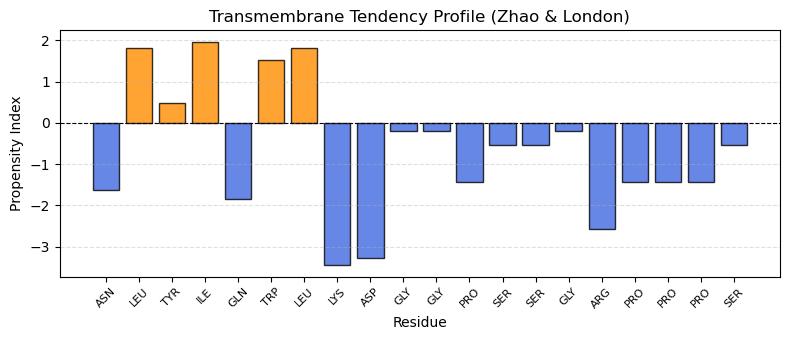

In [4]:
tt = msm.physchem.get_transmembrane_tendency(molsys, element='group', definition='zhao')
group_names = msm.get(molsys, element='group', name=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['darkorange' if val > 0 else 'royalblue' for val in tt]
ax.bar(range(len(tt)), tt, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xticks(range(len(tt)))
ax.set_xticklabels(group_names, rotation=45, fontsize=8)
ax.set_title('Transmembrane Tendency Profile (Zhao & London)')
ax.set_xlabel('Residue')
ax.set_ylabel('Propensity Index')
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()


## Alternative transmembrane scales

Setting `definition='senes'` extracts statistical pseudo-potential propensities derived from transmembrane helix structures:


In [5]:
tt_senes = msm.physchem.get_transmembrane_tendency(molsys, element='group', definition='senes')
print('Senes propensity scores:\n', tt_senes)


Senes propensity scores:
 [[0.89, 12.78, 6.28], [-0.64, 17.34, 8.61], [-0.42, 13.04, 6.2], [-0.56, 14.34, 10.69], [1.21, 10.46, 2.59], [-0.85, 11.65, 7.2], [-0.64, 17.34, 8.61], [1.66, 11.11, 2.09], [1.19, 14.25, 8.98], [-0.01, 13.86, 6], [-0.01, 13.86, 6], [0.83, 18.09, 3.53], [0.1, 13.86, 6], [0.1, 13.86, 6], [-0.01, 13.86, 6], [1.55, 9.34, 4.68], [0.83, 18.09, 3.53], [0.83, 18.09, 3.53], [0.83, 18.09, 3.53], [0.1, 13.86, 6]]


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query residue names and attributes with {func}`molsysmt.basic.get`.
- {ref}`Get hydrophobicity <Tutorial_Get_hydrophobicity>`: Query residue hydrophobicity with {func}`molsysmt.physchem.get_hydrophobicity`.
:::
